In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv


In [3]:
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [9]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Married'] = df['Married'].fillna(df['Married'].mode()[0])

df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])

df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [10]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [11]:
df['TotalIncome'] = (
    df['ApplicantIncome']
    + df['CoapplicantIncome']
)

In [12]:
df['Income_Category'] = pd.qcut(
    df['TotalIncome'],
    q=3,
    labels=[
        'Low Income',
        'Medium Income',
        'High Income'
    ]
)

In [13]:
df[['TotalIncome','Income_Category']].head()

,TotalIncome,Income_Category
0,5849.0,Medium Income
1,6091.0,Medium Income
2,3000.0,Low Income
3,4941.0,Medium Income
4,6000.0,Medium Income


In [14]:
print("Total Applicants:", len(df))

Total Applicants: 614


In [15]:
approval_rate = (
    (df['Loan_Status'] == 'Y').mean()
    * 100
)

print(
    "Loan Approval Rate:",
    round(approval_rate,2),
    "%"
)

Loan Approval Rate: 68.73 %


In [16]:
print(
    "Average Income:",
    round(df['ApplicantIncome'].mean(),2)
)

Average Income: 5403.46


In [17]:
print(
    "Average Loan Amount:",
    round(df['LoanAmount'].mean(),2)
)

Average Loan Amount: 145.75


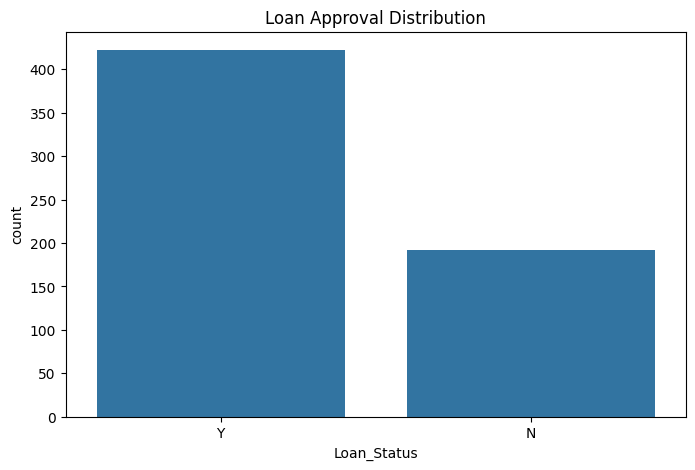

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Loan_Status'
)

plt.title('Loan Approval Distribution')

plt.savefig(
    'loan_approval_distribution.png',
    bbox_inches='tight'
)

plt.show()

In [19]:
credit_history = pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
)

credit_history

Loan_Status,N,Y
Credit_History,,
0.0,82,7
1.0,110,415


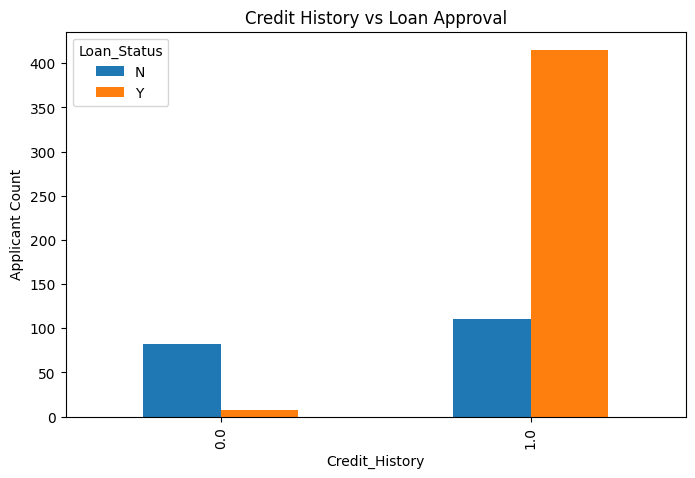

In [20]:
credit_history.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Credit History vs Loan Approval')

plt.ylabel('Applicant Count')

plt.savefig(
    'credit_history_vs_approval.png',
    bbox_inches='tight'
)

plt.show()

In [21]:
income_approval = pd.crosstab(
    df['Income_Category'],
    df['Loan_Status']
)

income_approval

Loan_Status,N,Y
Income_Category,,
Low Income,66,139
Medium Income,59,145
High Income,67,138


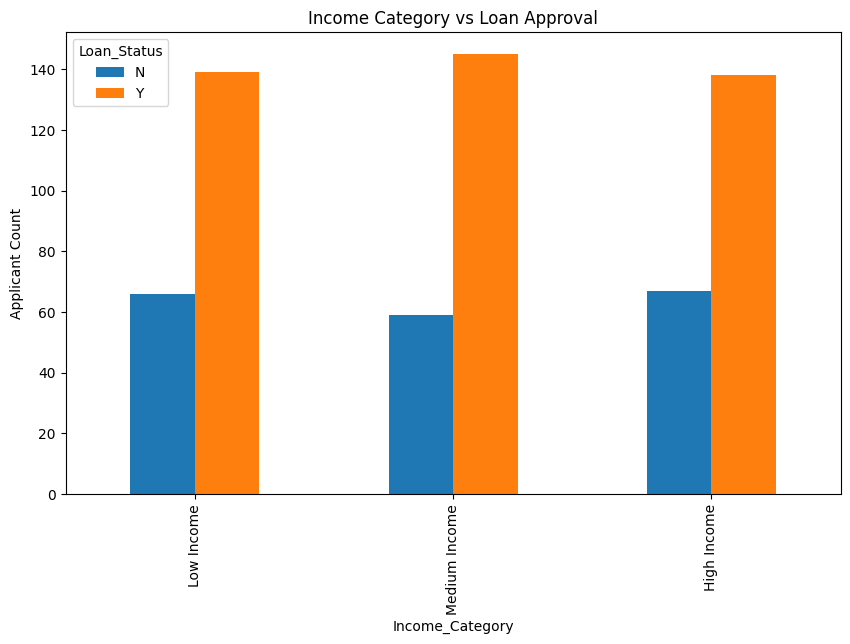

In [22]:
income_approval.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Income Category vs Loan Approval')

plt.ylabel('Applicant Count')

plt.savefig(
    'income_vs_approval.png',
    bbox_inches='tight'
)

plt.show()

In [23]:
education_approval = pd.crosstab(
    df['Education'],
    df['Loan_Status']
)

education_approval

Loan_Status,N,Y
Education,,
Graduate,140,340
Not Graduate,52,82


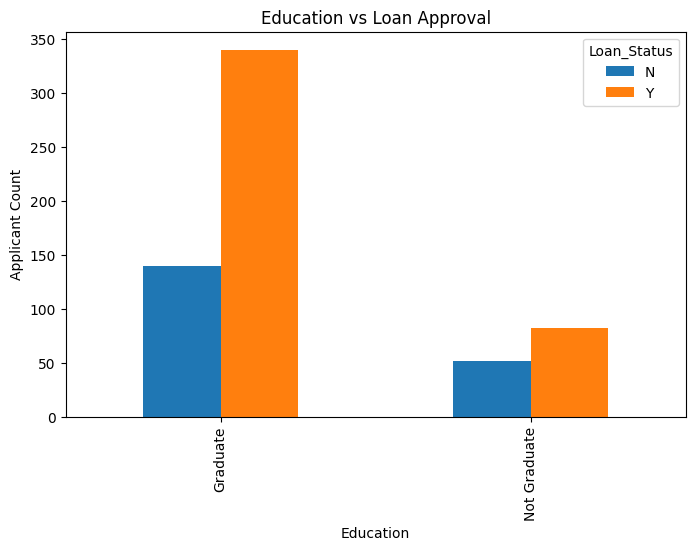

In [24]:
education_approval.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Education vs Loan Approval')

plt.ylabel('Applicant Count')

plt.savefig(
    'education_vs_approval.png',
    bbox_inches='tight'
)

plt.show()

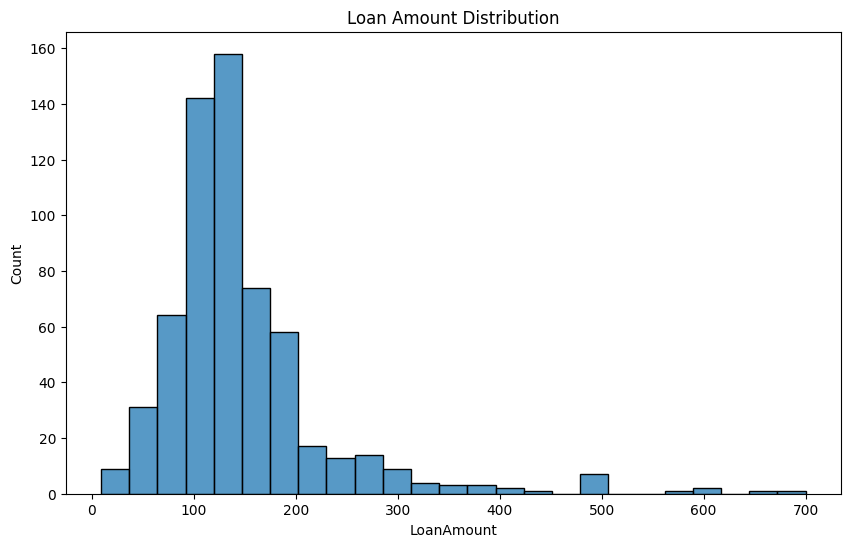

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['LoanAmount'],
    bins=25
)

plt.title('Loan Amount Distribution')

plt.savefig(
    'loan_amount_distribution.png',
    bbox_inches='tight'
)

plt.show()

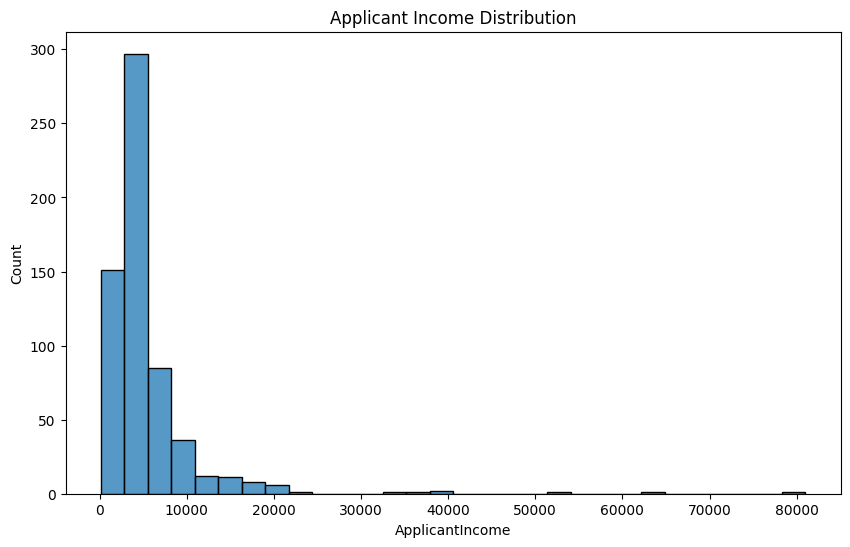

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['ApplicantIncome'],
    bins=30
)

plt.title('Applicant Income Distribution')

plt.savefig(
    'applicant_income_distribution.png',
    bbox_inches='tight'
)

plt.show()